# 🚀 Spark ML - Recap

**Machine Learning with Spark** — what it is, when to use it, and how it fits into a data pipeline.

📚 **Official docs:** [Spark MLlib Guide](https://spark.apache.org/docs/latest/ml-guide.html)

---

### Spark ML vs scikit-learn

| | scikit-learn | Spark ML |
|---|---|---|
| **Runs on** | 1 machine | Distributed cluster |
| **Data size** | Fits in RAM | Terabytes+ |
| **Algorithms** | Huge library | Essentials (regression, classification, clustering) |
| **Speed (small data)** | Faster | Slower (overhead) |
| **Speed (big data)** | Crashes | Scales |
| **Use case** | Data scientist experimenting | ML step inside a data pipeline |

**Key insight for Data Engineers:** You integrate ML training as a step in the pipeline. The data is already in Spark — no need to export to Pandas.

---
## 0. Setup

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Spark ML Recap") \
    .master("local[*]") \
    .getOrCreate()

print(f"Spark version: {spark.version}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/20 01:36:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.3


---
## Part 1: Regression 📈

**Goal:** Predict the `price` of a flat based on `bedrooms`, `surface`, and `floors`.

Regression = predicting a **continuous value** (a number).

📚 [Regression docs](https://spark.apache.org/docs/latest/mllib-linear-methods.html)

### 1.1 Load the data

In [2]:
!curl -s https://wagon-public-datasets.s3.amazonaws.com/flats.csv > flats.csv
print("Downloaded!")

Downloaded!


In [3]:
flats_df = spark.read.csv("flats.csv", header=True, inferSchema=True)
flats_df.show()
print(f"Total rows: {flats_df.count()}")

+------+--------+-------+------+
| price|bedrooms|surface|floors|
+------+--------+-------+------+
| 274.0|       3|   1830|   2.0|
| 500.0|       4|   2120|   1.0|
| 320.0|       3|   1260|   1.0|
| 445.5|       3|   1880|   1.0|
| 637.5|       3|   1680|   1.0|
| 460.0|       2|   2730|   1.0|
| 259.0|       3|   1270|   1.5|
| 950.0|       3|   2780|   1.0|
| 550.0|       3|   1930|   2.0|
| 265.5|       3|   1860|   1.0|
| 162.0|       4|   1460|   1.0|
|2395.0|       4|   3800|   2.0|
| 385.0|       3|   1070|   1.0|
| 230.0|       3|   1010|   1.0|
| 665.0|       3|   1940|   1.5|
| 412.0|       4|   3360|   2.0|
| 177.5|       3|   1220|   1.0|
| 330.0|       4|   2000|   1.0|
| 445.0|       4|   2430|   1.5|
| 139.5|       2|   1230|   2.0|
+------+--------+-------+------+
only showing top 20 rows

Total rows: 1000


In [4]:
flats_df.printSchema()

root
 |-- price: double (nullable = true)
 |-- bedrooms: integer (nullable = true)
 |-- surface: integer (nullable = true)
 |-- floors: double (nullable = true)



In [5]:
# Quick stats on the data
flats_df.describe().show()

26/03/20 01:38:55 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+-----------------+------------------+
|summary|             price|          bedrooms|          surface|            floors|
+-------+------------------+------------------+-----------------+------------------+
|  count|              1000|              1000|             1000|              1000|
|   mean| 547.1428170000004|             3.416|         2120.831|             1.502|
| stddev|355.67410614774235|1.3178318104677398|952.2969242157989|0.5447869242123864|
|    min|              82.5|                 0|              290|               1.0|
|    max|            3300.0|                33|             8020|               3.5|
+-------+------------------+------------------+-----------------+------------------+



### 1.2 VectorAssembler — Why vectors?

Spark ML needs all features in a **single vector column**. Why?

- Optimized for distributed linear algebra operations
- Supports **sparse vectors** (imagine 10,000 features where most are zeros — only stores non-zero values)
- Efficient to partition and move between workers

📚 [VectorAssembler docs](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.feature.VectorAssembler.html)

In [6]:
from pyspark.ml.feature import VectorAssembler

feature_cols = ["bedrooms", "surface", "floors"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
flats_assembled = assembler.transform(flats_df)

# See the vector column
flats_assembled.select("bedrooms", "surface", "floors", "features", "price").show(5, truncate=False)

+--------+-------+------+----------------+-----+
|bedrooms|surface|floors|features        |price|
+--------+-------+------+----------------+-----+
|3       |1830   |2.0   |[3.0,1830.0,2.0]|274.0|
|4       |2120   |1.0   |[4.0,2120.0,1.0]|500.0|
|3       |1260   |1.0   |[3.0,1260.0,1.0]|320.0|
|3       |1880   |1.0   |[3.0,1880.0,1.0]|445.5|
|3       |1680   |1.0   |[3.0,1680.0,1.0]|637.5|
+--------+-------+------+----------------+-----+
only showing top 5 rows



### 1.3 Train / Test split

In [22]:
train_df, test_df = flats_assembled.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train_df.count()} rows")
print(f"Test:  {test_df.count()} rows")

Train: 838 rows
Test:  162 rows


### 1.4 Model 1 — Linear Regression

The simplest model: draws a line (or hyperplane) through the data.

📚 [LinearRegression docs](https://spark.apache.org/docs/3.5.5/ml-classification-regression.html#linear-regression)

In [23]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(featuresCol="features", labelCol="price")
lr_model = lr.fit(train_df)

# What did it learn?
print(f"Coefficients: {lr_model.coefficients}")
print(f"Intercept:    {lr_model.intercept}")
print()
print("Interpretation:")
for col_name, coeff in zip(feature_cols, lr_model.coefficients):
    print(f"  {col_name}: {coeff:.4f}")

26/03/20 01:45:41 WARN Instrumentation: [86a040d4] regParam is zero, which might cause numerical instability and overfitting.
26/03/20 01:45:41 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/03/20 01:45:41 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Coefficients: [-16.36522326970365,0.2737925456244861,-4.908976455573093]
Intercept:    24.129455441138383

Interpretation:
  bedrooms: -16.3652
  surface: 0.2738
  floors: -4.9090


### 1.5 Model 2 — Decision Tree Regressor

Instead of a line, it makes decisions like a flowchart: "Is surface > 2000? If yes, go left. Is bedrooms > 3? If yes, predict 500."

📚 [DecisionTreeRegressor docs](https://spark.apache.org/docs/3.5.5/ml-classification-regression.html#decision-tree-regression)

In [24]:
from pyspark.ml.regression import DecisionTreeRegressor

dt = DecisionTreeRegressor(featuresCol="features", labelCol="price")
dt_model = dt.fit(train_df)

print(f"Tree depth: {dt_model.depth}")
print(f"Number of nodes: {dt_model.numNodes}")

Tree depth: 5
Number of nodes: 57


In [26]:
# print(dt_model.toDebugString)

### 1.6 Model 3 — Random Forest Regressor

Many decision trees combined. Each tree sees a random subset of the data. The final prediction is the average of all trees. More robust than a single tree.

📚 [RandomForestRegressor docs](https://spark.apache.org/docs/3.5.5/ml-classification-regression.html#random-forest-regression)

In [27]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(featuresCol="features", labelCol="price", numTrees=10)
rf_model = rf.fit(train_df)

print(f"Number of trees: {rf_model.getNumTrees}")
print(f"Feature importances: {rf_model.featureImportances}")
print()
for col_name, importance in zip(feature_cols, rf_model.featureImportances):
    print(f"  {col_name}: {importance:.4f}")

Number of trees: 10
Feature importances: (3,[0,1,2],[0.18431228895853094,0.6921113459870964,0.12357636505437256])

  bedrooms: 0.1843
  surface: 0.6921
  floors: 0.1236


### 1.7 Evaluate — Compare the 3 models

📚 [RegressionEvaluator docs](https://spark.apache.org/docs/3.5.5/ml-tuning.html)

In [28]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator_rmse = RegressionEvaluator(labelCol="price", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="price", metricName="r2")

models = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
}

print(f"{'Model':<25} {'RMSE':>10} {'R²':>10}")
print("-" * 47)

for name, model in models.items():
    preds = model.transform(test_df)
    rmse = evaluator_rmse.evaluate(preds)
    r2 = evaluator_r2.evaluate(preds)
    print(f"{name:<25} {rmse:>10.2f} {r2:>10.4f}")

Model                           RMSE         R²
-----------------------------------------------
Linear Regression             244.44     0.6257
Decision Tree                 273.02     0.5331
Random Forest                 291.06     0.4693


### 1.8 Visualize predictions vs real prices

Spark does NOT plot. Convert to Pandas → use Plotly Express.

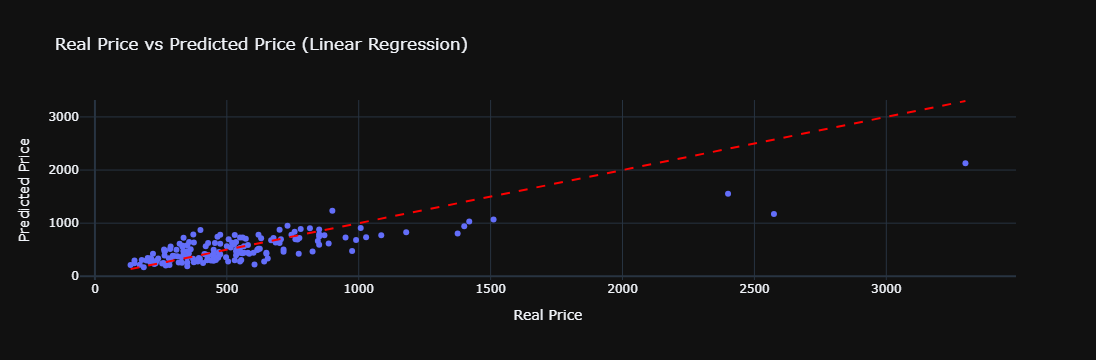

In [29]:
# pip install plotly if needed
import plotly.express as px

# Pick the best model and get predictions on test set
best_preds = lr_model.transform(test_df)

# Convert to Pandas (only the columns we need — never convert millions of rows!)
pdf = best_preds.select("price", "prediction").toPandas()

fig = px.scatter(
    pdf,
    x="price",
    y="prediction",
    title="Real Price vs Predicted Price (Linear Regression)",
    labels={"price": "Real Price", "prediction": "Predicted Price"},
)

# Perfect prediction line
fig.add_shape(
    type="line",
    x0=pdf["price"].min(), y0=pdf["price"].min(),
    x1=pdf["price"].max(), y1=pdf["price"].max(),
    line=dict(dash="dash", color="red"),
)

fig.update_layout(
    template='plotly_dark'
)

fig.show()

---
## Part 2: Classification 🏷️

**Goal:** Predict a **category** instead of a number.

We'll predict if a flat is `expensive` (1) or `cheap` (0) based on the same features.

📚 [Classification docs](https://spark.apache.org/docs/3.5.5/ml-classification-regression.html#classification)

### 2.1 Create a label column

In [30]:
from pyspark.sql.functions import when, col

# Create binary label: expensive (1) if price > 400, cheap (0) otherwise
classified_df = flats_assembled.withColumn(
    "label",
    when(col("price") > 400, 1.0).otherwise(0.0)
)

classified_df.select("price", "label", "features").show(10)

# How balanced is the data?
classified_df.groupBy("label").count().show()

+-----+-----+----------------+
|price|label|        features|
+-----+-----+----------------+
|274.0|  0.0|[3.0,1830.0,2.0]|
|500.0|  1.0|[4.0,2120.0,1.0]|
|320.0|  0.0|[3.0,1260.0,1.0]|
|445.5|  1.0|[3.0,1880.0,1.0]|
|637.5|  1.0|[3.0,1680.0,1.0]|
|460.0|  1.0|[2.0,2730.0,1.0]|
|259.0|  0.0|[3.0,1270.0,1.5]|
|950.0|  1.0|[3.0,2780.0,1.0]|
|550.0|  1.0|[3.0,1930.0,2.0]|
|265.5|  0.0|[3.0,1860.0,1.0]|
+-----+-----+----------------+
only showing top 10 rows

+-----+-----+
|label|count|
+-----+-----+
|  0.0|  397|
|  1.0|  603|
+-----+-----+



### 2.2 Train a Logistic Regression

Despite the name, Logistic Regression is a **classification** algorithm. It predicts the probability of belonging to a class.

📚 [LogisticRegression docs](https://spark.apache.org/docs/3.5.5/ml-classification-regression.html#logistic-regression)

In [31]:
from pyspark.ml.classification import LogisticRegression

train_clf, test_clf = classified_df.randomSplit([0.8, 0.2], seed=42)

log_reg = LogisticRegression(featuresCol="features", labelCol="label")
log_reg_model = log_reg.fit(train_clf)

In [32]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

clf_preds = log_reg_model.transform(test_clf)

clf_preds.select("price", "label", "prediction", "probability").show(10, truncate=False)

+-----+-----+----------+----------------------------------------+
|price|label|prediction|probability                             |
+-----+-----+----------+----------------------------------------+
|135.0|0.0  |0.0       |[0.8251905712342129,0.1748094287657871] |
|149.5|0.0  |0.0       |[0.7865430163603107,0.21345698363968935]|
|150.0|0.0  |0.0       |[0.7312232396150454,0.26877676038495457]|
|169.9|0.0  |0.0       |[0.7822495199176732,0.21775048008232678]|
|177.5|0.0  |0.0       |[0.7249008889404254,0.27509911105957463]|
|185.0|0.0  |0.0       |[0.859046276258276,0.140953723741724]   |
|195.0|0.0  |0.0       |[0.7312232396150454,0.26877676038495457]|
|200.0|0.0  |0.0       |[0.6420958501304017,0.3579041498695983] |
|210.0|0.0  |0.0       |[0.7312232396150454,0.26877676038495457]|
|210.0|0.0  |0.0       |[0.759932351541445,0.240067648458555]   |
+-----+-----+----------+----------------------------------------+
only showing top 10 rows



In [33]:
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

accuracy = evaluator_acc.evaluate(clf_preds)
f1 = evaluator_f1.evaluate(clf_preds)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.7099
F1 Score: 0.7148


---
## Part 3: Spark ML Pipelines 🔗

In real life, you don't run each step manually. You chain them into a **Pipeline** — a sequence of stages that run in order.

This is the key concept for Data Engineers: the ML model becomes **just another step in the data pipeline**.

📚 [Pipeline docs](https://spark.apache.org/docs/3.5.5/ml-pipeline.html)

In [34]:
from pyspark.ml import Pipeline

# Start from the RAW data — no need to pre-assemble features
train_raw, test_raw = flats_df.randomSplit([0.8, 0.2], seed=42)

# Define the pipeline: assembler → model
pipeline = Pipeline(stages=[
    VectorAssembler(inputCols=["bedrooms", "surface", "floors"], outputCol="features"),
    LinearRegression(featuresCol="features", labelCol="price")
])

# One call does everything
pipeline_model = pipeline.fit(train_raw)

# Predict on raw test data — the pipeline handles the transformations
pipeline_preds = pipeline_model.transform(test_raw)
pipeline_preds.select("bedrooms", "surface", "floors", "price", "prediction").show()

26/03/20 01:58:31 WARN Instrumentation: [2feab2bd] regParam is zero, which might cause numerical instability and overfitting.


+--------+-------+------+------+------------------+
|bedrooms|surface|floors| price|        prediction|
+--------+-------+------+------+------------------+
|       2|    830|   1.0| 135.0| 213.7378453144815|
|       3|   1010|   1.0| 149.5|246.65528025718532|
|       3|   1200|   1.0| 150.0|298.67586392583763|
|       3|    910|   1.5| 169.9| 216.8215374669502|
|       3|   1220|   1.0| 177.5|304.15171483832734|
|       2|    670|   1.0| 185.0| 169.9310380145637|
|       3|   1200|   1.0| 195.0|298.67586392583763|
|       2|   1320|   1.5| 200.0| 345.4417044426931|
|       3|   1200|   1.0| 210.0|298.67586392583763|
|       4|   1130|   1.0| 210.0|263.14516246242005|
|       3|   1350|   1.0| 211.0|339.74474576951053|
|       3|   1280|   2.0| 215.0|315.67029112022345|
|       3|   1650|   1.0| 220.0| 421.8825094568564|
|       3|    960|   1.0| 225.0|  232.965652975961|
|       3|   1010|   1.0| 230.0|246.65528025718532|
|       2|   1140|   1.5| 235.0| 296.1590462302856|
|       2|  

### 3.1 Save and load a pipeline model

In a real pipeline (like the NYC Taxis challenge), you save the trained model to a bucket so the data scientist can use it later.

In [35]:
# Save locally (in production this would be gs://your-bucket/models/)
pipeline_model.write().overwrite().save("saved_model")
print("Model saved!")

# Load it back
from pyspark.ml import PipelineModel
loaded_model = PipelineModel.load("saved_model")

# Use the loaded model
loaded_preds = loaded_model.transform(test_raw)
loaded_preds.select("price", "prediction").show(5)
print("Model loaded and working!")

Model saved!


+-----+------------------+
|price|        prediction|
+-----+------------------+
|135.0| 213.7378453144815|
|149.5|246.65528025718532|
|150.0|298.67586392583763|
|169.9| 216.8215374669502|
|177.5|304.15171483832734|
+-----+------------------+
only showing top 5 rows

Model loaded and working!


---
## Recap — Key Takeaways

| Concept | What it does |
|---|---|
| `VectorAssembler` | Combines feature columns into a single vector |
| `LinearRegression` | Predicts a continuous value (price) |
| `DecisionTreeRegressor` | Predicts using a flowchart of decisions |
| `RandomForestRegressor` | Many trees combined — more robust |
| `LogisticRegression` | Classifies into categories (expensive/cheap) |
| `Pipeline` | Chains transformations + model into one object |
| `.save()` / `.load()` | Persist the model to disk or cloud storage |
| `.toPandas()` | Convert Spark DF to Pandas for plotting |

### When to use Spark ML over scikit-learn?

- Your data is **already in Spark** (part of a larger pipeline)
- Your data is **too big** for one machine
- You need the model training as **a step in an automated pipeline** (Airflow + DataProc)

### Links

- [Spark MLlib Guide](https://spark.apache.org/docs/3.5.5/ml-guide.html)
- [All available algorithms](https://spark.apache.org/docs/3.5.5/ml-classification-regression.html)
- [Feature transformers](https://spark.apache.org/docs/3.5.5/ml-features.html)
- [Pipeline docs](https://spark.apache.org/docs/3.5.5/ml-pipeline.html)
- [Model tuning & cross-validation](https://spark.apache.org/docs/3.5.5/ml-tuning.html)

In [36]:
spark.stop()
print("Done! 🎉")

Done! 🎉
